
# Triadic Cell Notebook v35
## Observables-loaded recursive beam

This notebook continues the inversion from v34.

The claim is:

- control should come from the **core fold-energy**
- recursion should be fed by **observables**
- branch laws such as KRRB / SILR / Samson / AHRC should emerge as readouts of the live beam

So the key move in v35 is:

$$
\text{external data} \to \text{observable packet} \to \text{recursive loop}
$$

Instead of using higher-level laws as direct control knobs, we let new information enter as
cycle-by-cycle observables.

That means each recursion cycle receives:

- the current query state
- the current active branches
- a new observable packet from outside the loop

The loop then asks:

- which branch predicts the observed packet best?
- which branch has the lowest fold energy?
- which branch should survive to the next cycle?

This is the first notebook in the line where **data enters the recursion loop as observables**.



## Practical meaning

This is still runtime control, not base-model training.

The point is narrower:

- v32 showed that breathing across branches improves identity
- v33 showed that explicit KRRB control can overconstrain
- v34 inverted the stack so branch laws become outcomes
- v35 now loads fresh information into the loop through observable packets

This is the mechanism you were pointing at:

$$
\text{recursive loop} + \text{observable injection} \to \text{adaptive branch update}
$$

The core outputs are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `observables_summary`
- `obs_trace_df`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Core fold decomposition


In [5]:

def directional_coeffs(x: np.ndarray):
    return U @ x

def reconstruct_from_coeffs(c: np.ndarray):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query: np.ndarray, target: np.ndarray):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    active_dirs = int(np.sum(np.abs(aq) > 0.10))
    boundary_complexity = int(np.sum(np.abs(at) > 0.12))
    boundary_eff = max(1.0, boundary_complexity / 2.0)
    nyquist_score = float(active_dirs / boundary_eff)

    return {
        "R": R,
        "M": M,
        "E": E,
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
        "aligned_ratio": float(aligned_energy / total_energy),
        "nyquist_score": nyquist_score,
    }



## Candidate evaluation and field emission


In [6]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.25 * (1.0 - retrieve_fit)
        + 0.20 * max(0.0, 1.0 - split["nyquist_score"])
    )

    closure_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.90 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.50 * bridge_energy
    )

    declaration_score = closure_score + 0.18 * min(split["nyquist_score"], 2.0)

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "nyquist_score": split["nyquist_score"],
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def produce_fields_for_class(query: np.ndarray, cls: int, threshold: float):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    mode = "retrieve" if ev["declaration_score"] >= threshold else "grow"

    closure_permission = sigmoid(8.0 * (ev["declaration_score"] - threshold))
    nyquist_permission = sigmoid(5.0 * (ev["nyquist_score"] - 1.0))
    margin_permission = sigmoid(10.0 * (margin - 0.05))
    permission = float(closure_permission * nyquist_permission * margin_permission)

    retrieve_mask = normalize01(ev["R"] * permission)
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "mode": mode,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "closure_score": ev["closure_score"],
        "declaration_score": ev["declaration_score"],
        "nyquist_score": ev["nyquist_score"],
        "permission": permission,
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query: np.ndarray, threshold: float):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"], threshold)



## Observable map

We define a small observable channel that is produced from the declared value.
This is synthetic, but the point is structural:

- the loop does not get direct labels
- it gets observable packets
- branches are scored by how well they predict those observables


In [7]:

obs_dim = 3

OBS_W = np.array([
    [0.80, 0.10, 0.35, 0.05, 0.20, 0.10],
    [0.10, 0.75, 0.10, 0.30, 0.05, 0.25],
    [0.20, 0.10, 0.55, 0.10, 0.45, 0.20],
], dtype=float)

def observable_from_declared(declared_value: np.ndarray):
    o = OBS_W @ declared_value
    return normalize01(o)

def make_observable_packet(true_cls: int, query_mode: str, cycle: int, total_cycles: int):
    target_declared = chains[true_cls][2]
    full_obs = observable_from_declared(target_declared)

    # reveal schedule: more information arrives each cycle
    reveal = (cycle + 1) / total_cycles

    if query_mode == "existing":
        noise = 0.01
        reveal = max(reveal, 0.85)
    elif query_mode == "noisy":
        noise = 0.06
    elif query_mode == "partial":
        noise = 0.03
        reveal = 0.35 + 0.55 * reveal
    elif query_mode == "ambiguous":
        noise = 0.05
        reveal = 0.45 + 0.45 * reveal
    else:  # inverse_hint
        noise = 0.05
        reveal = 0.40 + 0.50 * reveal

    mask = np.zeros(obs_dim, dtype=float)
    n_reveal = max(1, int(np.ceil(reveal * obs_dim)))
    mask[:n_reveal] = 1.0

    packet = full_obs * mask + rng.normal(0.0, noise, size=full_obs.shape[0])
    return normalize01(packet)



## Base branch energy with observable misfit

Control still uses one energy function.

The new ingredient is:

$$
\text{observable misfit} = \|O_t - \hat O_i\|
$$

where \(O_t\) is the incoming observable packet and \(\hat O_i\) is the predicted observable for branch \(i\).


In [8]:

def softmax_stable(x: np.ndarray):
    z = x - np.max(x)
    ez = np.exp(z)
    return ez / (np.sum(ez) + 1e-8)

def pairwise_alias_pressure(values: list[float], tau: float = 0.08):
    if len(values) < 2:
        return 0.0
    vals = []
    for i in range(len(values)):
        for j in range(i + 1, len(values)):
            vals.append(np.exp(-abs(values[i] - values[j]) / tau))
    return float(np.mean(vals))

def observable_misfit(obs_packet: np.ndarray, predicted_obs: np.ndarray):
    return float(np.mean(np.abs(obs_packet - predicted_obs)))

def branch_energy(
    declaration_score: float,
    missing_mass: float,
    contradiction_mass: float,
    retrieve_mass: float,
    alias_pressure: float,
    obs_misfit: float,
):
    alpha = 0.90
    beta = 0.50
    gamma = 0.75
    delta = 0.30
    eta = 0.30
    rho = 0.85
    return float(
        alpha * missing_mass
        + beta * contradiction_mass
        - gamma * declaration_score
        - delta * retrieve_mass
        + eta * alias_pressure
        + rho * obs_misfit
    )



## Calibration


In [9]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, _, _ = triadic_query(q)
        rows.append({
            "query": q,
            "true_class": cls,
            "query_mode": mode,
            "declaration_score": best["declaration_score"],
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["declaration_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


1.2780704554873628


## v32-style breathing beam baseline


In [10]:

def top_candidate_classes(query: np.ndarray, k: int = 3):
    results = [triadic_evaluate(query, c) for c in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    return [r["class"] for r in results[:k]]

def breathing_beam_v32(query: np.ndarray, threshold: float, beam_width: int = 3, cycles: int = 4, exhale_steps: int = 2, step_size: float = 0.45, damping: float = 0.85):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{"cls": cls, "query": query.copy()} for cls in init_classes]

    for _ in range(cycles):
        expanded = []

        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                update = step_size * f["signed_correction"]
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy()})

            for alt_cls in top_candidate_classes(q, k=min(2, n_classes)):
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy()})

        scored = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            rank_score = (
                0.70 * f["declaration_score"]
                + 0.20 * f["permission"]
                - 0.35 * float(f["missing_mask"].mean())
                - 0.10 * float(f["contradiction_mask"].mean())
            )
            scored.append({
                **item,
                "rank_score": float(rank_score),
            })

        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["rank_score"] > best_per_class[cls]["rank_score"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["rank_score"], reverse=True)[:beam_width]

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"], threshold)
    return final_best["query"], final_fields



## Observable-loaded recursive beam

Selection is driven by fold energy plus observable misfit.
KRRB, SILR, Samson, and AHRC are then measured from the active beam each cycle.


In [11]:

MARK1 = np.pi / 9.0

def observable_loaded_beam(
    query: np.ndarray,
    true_cls: int,
    query_mode: str,
    threshold: float,
    beam_width: int = 3,
    cycles: int = 4,
    exhale_steps: int = 2,
    step_size: float = 0.45,
    damping: float = 0.85,
):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls in init_classes]
    trace_rows = []

    for cycle in range(cycles):
        obs_packet = make_observable_packet(true_cls, query_mode, cycle, cycles)
        expanded = []

        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                update = step_size * f["signed_correction"]
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy(), "spawn_from": branch["spawn_from"]})

            for alt_cls in top_candidate_classes(q, k=min(2, n_classes)):
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy(), "spawn_from": cls})

        prelim = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            pred_obs = observable_from_declared(f["declared_value"])
            prelim.append((item, f, pred_obs))

        provisional_alias = pairwise_alias_pressure(
            [f["declaration_score"] for _, f, _ in prelim],
            tau=0.10,
        )

        scored = []
        energies = []

        for item, f, pred_obs in prelim:
            missing_mass = float(f["missing_mask"].mean())
            contradiction_mass = float(f["contradiction_mask"].mean())
            retrieve_mass = float(f["retrieve_mask"].mean())
            obs_mis = observable_misfit(obs_packet, pred_obs)

            e = branch_energy(
                declaration_score=f["declaration_score"],
                missing_mass=missing_mass,
                contradiction_mass=contradiction_mass,
                retrieve_mass=retrieve_mass,
                alias_pressure=provisional_alias,
                obs_misfit=obs_mis,
            )

            scored.append({
                **item,
                "mode": f["mode"],
                "declaration_score": f["declaration_score"],
                "missing_mass": missing_mass,
                "retrieve_mass": retrieve_mass,
                "contradiction_mass": contradiction_mass,
                "permission": f["permission"],
                "obs_misfit": obs_mis,
                "energy": e,
            })
            energies.append(e)

        energies = np.array(energies, dtype=float)
        probs = softmax_stable(-energies)

        # emergent observables of the active beam
        krrb_entropy = float(-np.sum(probs * np.log(probs + 1e-8)))
        silr_mu = float(np.mean(energies))
        silr_sd = float(np.std(energies) + 1e-8)
        ahrc_pressure = pairwise_alias_pressure(energies.tolist(), tau=0.08)

        for idx, item in enumerate(scored):
            tension = 0.65 * item["missing_mass"] + 0.35 * item["contradiction_mass"]
            samson_delta = float(tension - MARK1)
            samson_scale = float(0.25 + 0.35 * np.tanh(abs(samson_delta) * 3.0))
            silr_z = float((item["energy"] - silr_mu) / silr_sd)

            item["prob"] = float(probs[idx])
            item["silr_z"] = silr_z
            item["samson_delta"] = samson_delta
            item["samson_scale"] = samson_scale
            item["krrb_entropy"] = krrb_entropy
            item["ahrc_pressure"] = ahrc_pressure
            item["obs_packet_0"] = float(obs_packet[0])
            item["obs_packet_1"] = float(obs_packet[1])
            item["obs_packet_2"] = float(obs_packet[2])

        # keep best instance per class by lowest energy
        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["energy"] < best_per_class[cls]["energy"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["energy"])[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "mode": item["mode"],
                "energy": item["energy"],
                "prob": item["prob"],
                "declaration_score": item["declaration_score"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "contradiction_mass": item["contradiction_mass"],
                "permission": item["permission"],
                "obs_misfit": item["obs_misfit"],
                "silr_z": item["silr_z"],
                "samson_delta": item["samson_delta"],
                "samson_scale": item["samson_scale"],
                "krrb_entropy": item["krrb_entropy"],
                "ahrc_pressure": item["ahrc_pressure"],
                "spawn_from": item["spawn_from"],
                "obs_packet_0": item["obs_packet_0"],
                "obs_packet_1": item["obs_packet_1"],
                "obs_packet_2": item["obs_packet_2"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"], threshold)
    return final_best["query"], pd.DataFrame(trace_rows), final_fields



## Single example


In [12]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

q_beam, beam_final = breathing_beam_v32(q0, retrieve_threshold)
q_obs, obs_trace_df, obs_final = observable_loaded_beam(
    q0,
    true_cls=example_cls,
    query_mode=example_mode,
    threshold=retrieve_threshold,
)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "beam_final_class": beam_final["predicted_class"],
    "obs_final_class": obs_final["predicted_class"],
    "beam_missing_mass": float(beam_final["missing_mask"].mean()),
    "obs_missing_mass": float(obs_final["missing_mask"].mean()),
    "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
    "obs_retrieve_mass": float(obs_final["retrieve_mask"].mean()),
}])
single_example


,true_class,query_mode,beam_final_class,obs_final_class,beam_missing_mass,obs_missing_mass,beam_retrieve_mass,obs_retrieve_mass
0,1,partial,3,1,0.95307,0.665611,0.04693,0.167717


In [13]:

obs_trace_df.head(12)


,cycle,beam_rank,class,mode,energy,prob,declaration_score,missing_mass,retrieve_mass,contradiction_mass,...,obs_misfit,silr_z,samson_delta,samson_scale,krrb_entropy,ahrc_pressure,spawn_from,obs_packet_0,obs_packet_1,obs_packet_2
0,0,0,3,grow,0.688404,0.211167,0.318838,0.833177,0.166793,0.041177,...,0.203283,-0.880982,0.206911,0.443073,1.750032,0.182380,0,0.469310,0.891992,0.013194
1,0,1,1,grow,0.812320,0.186556,-0.018445,0.666667,0.128202,0.077853,...,0.192574,-0.495895,0.111516,0.362911,1.750032,0.182380,-1,0.469310,0.891992,0.013194
2,0,2,0,grow,1.278830,0.117006,0.168517,0.999994,0.000005,0.093402,...,0.499048,0.953849,0.333621,0.516685,1.750032,0.182380,-1,0.469310,0.891992,0.013194
3,1,0,3,grow,0.590086,0.215676,0.515453,0.832079,0.167917,0.039065,...,0.223373,-0.998058,0.205458,0.442009,1.753878,0.141693,0,0.386937,0.906953,0.049147
4,1,1,1,grow,0.623350,0.208620,0.248689,0.666664,0.165797,0.073117,...,0.181494,-0.887134,0.109856,0.361347,1.753878,0.141693,-1,0.386937,0.906953,0.049147
5,1,2,0,grow,1.173113,0.120392,0.374960,0.999817,0.000183,0.088143,...,0.519647,0.946157,0.331665,0.515820,1.753878,0.141693,-1,0.386937,0.906953,0.049147
6,2,0,3,grow,0.306406,0.222191,0.660170,0.828349,0.171650,0.037062,...,0.039773,-1.167166,0.202333,0.439704,1.755978,0.112011,0,0.446259,0.845391,0.478010
7,2,1,1,grow,0.320635,0.219051,0.445374,0.666573,0.166718,0.068661,...,0.017950,-1.116057,0.108238,0.359817,1.755978,0.112011,-1,0.446259,0.845391,0.478010
8,2,2,0,grow,0.883267,0.124795,0.530641,0.998696,0.001304,0.083180,...,0.336524,0.904937,0.329200,0.514718,1.755978,0.112011,-1,0.446259,0.845391,0.478010
9,3,0,1,grow,0.211901,0.217604,0.593659,0.665611,0.167717,0.064470,...,0.028055,-0.987810,0.106146,0.357833,1.750148,0.109690,-1,0.423417,0.867436,0.567924



## Compare first pass vs v32 beam vs observable-loaded beam


In [14]:

rows_compare = []

for _, row in eval_df.iterrows():
    q = row["query"]
    true_class = int(row["true_class"])
    query_mode = row["query_mode"]

    first = produce_fields_best(q, retrieve_threshold)
    _, beam_final = breathing_beam_v32(q, retrieve_threshold)
    _, _, obs_final = observable_loaded_beam(
        q,
        true_cls=true_class,
        query_mode=query_mode,
        threshold=retrieve_threshold,
    )

    rows_compare.append({
        "true_class": true_class,
        "query_mode": query_mode,
        "first_correct": int(first["predicted_class"] == true_class),
        "beam_correct": int(beam_final["predicted_class"] == true_class),
        "obs_correct": int(obs_final["predicted_class"] == true_class),

        "first_missing_mass": float(first["missing_mask"].mean()),
        "beam_missing_mass": float(beam_final["missing_mask"].mean()),
        "obs_missing_mass": float(obs_final["missing_mask"].mean()),

        "first_retrieve_mass": float(first["retrieve_mask"].mean()),
        "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
        "obs_retrieve_mass": float(obs_final["retrieve_mask"].mean()),
    })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,beam_correct,obs_correct,first_missing_mass,beam_missing_mass,obs_missing_mass,first_retrieve_mass,beam_retrieve_mass,obs_retrieve_mass
0,0,existing,1,1,1,0.155701,0.099667,0.099667,0.844299,0.900333,0.900333
1,1,noisy,1,1,1,0.361475,0.317034,0.317034,0.638524,0.682966,0.682966
2,1,inverse_hint,1,1,1,0.660515,0.544234,0.544234,0.339482,0.455766,0.455766
3,1,inverse_hint,1,1,1,0.395642,0.214208,0.214208,0.437690,0.619125,0.619125
4,2,inverse_hint,0,0,0,0.495890,0.434498,0.434498,0.504106,0.565501,0.565501



## Core comparison


In [15]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "breathing_beam_accuracy": float(compare_df["beam_correct"].mean()),
    "observable_loaded_accuracy": float(compare_df["obs_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "breathing_beam_missing_mass": float(compare_df["beam_missing_mass"].mean()),
    "observable_loaded_missing_mass": float(compare_df["obs_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,breathing_beam_accuracy,observable_loaded_accuracy,first_pass_missing_mass,breathing_beam_missing_mass,observable_loaded_missing_mass
0,0.872143,0.88,0.897857,0.425414,0.309323,0.291219


In [16]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "beam_correct",
        "obs_correct",
        "first_missing_mass",
        "beam_missing_mass",
        "obs_missing_mass",
        "first_retrieve_mass",
        "beam_retrieve_mass",
        "obs_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["obs_vs_first_gain"] = by_mode_compare["obs_correct"] - by_mode_compare["first_correct"]
by_mode_compare["obs_vs_beam_gain"] = by_mode_compare["obs_correct"] - by_mode_compare["beam_correct"]
by_mode_compare["obs_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["obs_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("obs_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,beam_correct,obs_correct,first_missing_mass,beam_missing_mass,obs_missing_mass,first_retrieve_mass,beam_retrieve_mass,obs_retrieve_mass,obs_vs_first_gain,obs_vs_beam_gain,obs_missing_drop
4,partial,0.620155,0.635659,0.705426,0.662506,0.509968,0.463648,0.336988,0.480121,0.525725,0.085271,0.069767,0.198858
0,ambiguous,0.978355,0.991342,0.991342,0.619463,0.432045,0.428034,0.371157,0.556411,0.560421,0.012987,0.000000,0.191429
1,existing,1.000000,1.000000,1.000000,0.105301,0.068652,0.061294,0.890964,0.920610,0.922833,0.000000,0.000000,0.044007
2,inverse_hint,0.807143,0.821429,0.807143,0.582822,0.449368,0.436325,0.402877,0.522060,0.537484,0.000000,-0.014286,0.146497
3,noisy,1.000000,1.000000,1.000000,0.269847,0.170075,0.162917,0.723135,0.819984,0.825972,0.000000,0.000000,0.106930



## Partial-only focus


In [17]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_beam_accuracy": float(partial_df["beam_correct"].mean()),
    "partial_observable_accuracy": float(partial_df["obs_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_beam_missing_mass": float(partial_df["beam_missing_mass"].mean()),
    "partial_observable_missing_mass": float(partial_df["obs_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_beam_retrieve_mass": float(partial_df["beam_retrieve_mass"].mean()),
    "partial_observable_retrieve_mass": float(partial_df["obs_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_beam_accuracy,partial_observable_accuracy,partial_first_missing_mass,partial_beam_missing_mass,partial_observable_missing_mass,partial_first_retrieve_mass,partial_beam_retrieve_mass,partial_observable_retrieve_mass
0,0.620155,0.635659,0.705426,0.662506,0.509968,0.463648,0.336988,0.480121,0.525725



## Emergent branch observables


In [18]:

observables_summary = pd.DataFrame([{
    "mean_krrb_entropy": float(obs_trace_df["krrb_entropy"].mean()),
    "mean_abs_silr_z": float(np.abs(obs_trace_df["silr_z"]).mean()),
    "mean_samson_delta": float(obs_trace_df["samson_delta"].mean()),
    "mean_samson_scale": float(obs_trace_df["samson_scale"].mean()),
    "mean_ahrc_pressure": float(obs_trace_df["ahrc_pressure"].mean()),
    "mean_obs_misfit": float(obs_trace_df["obs_misfit"].mean()),
}])
observables_summary


,mean_krrb_entropy,mean_abs_silr_z,mean_samson_delta,mean_samson_scale,mean_ahrc_pressure,mean_obs_misfit
0,1.752509,0.92261,0.21382,0.438458,0.136443,0.218317



## Visual readout


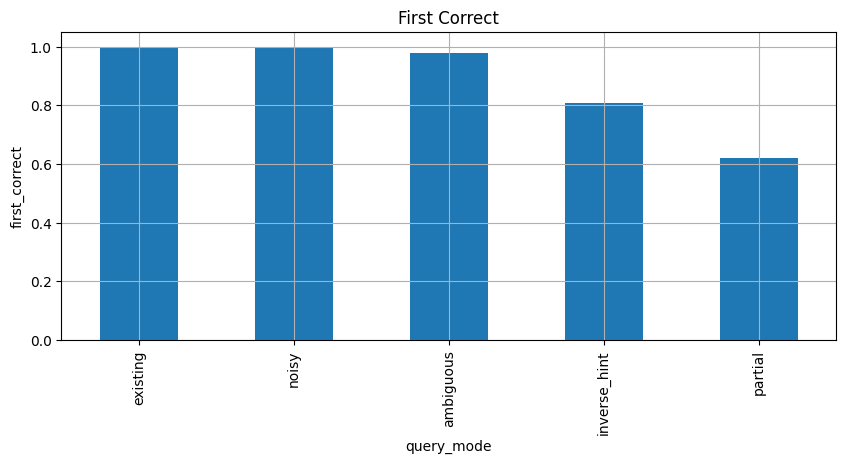

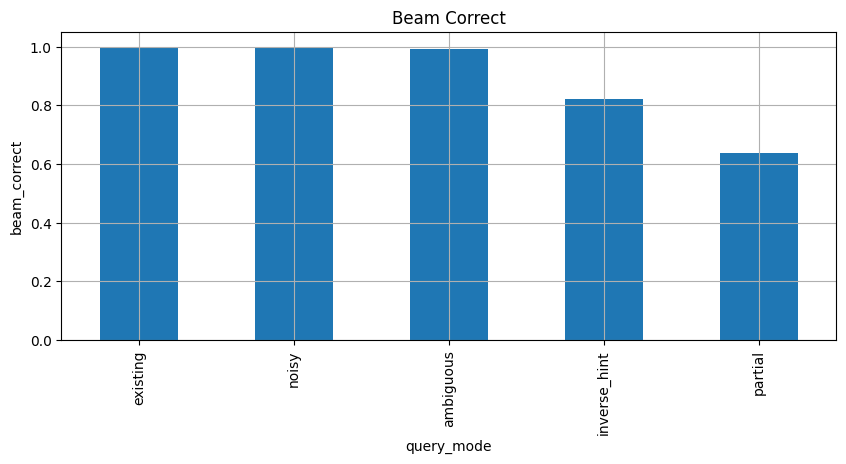

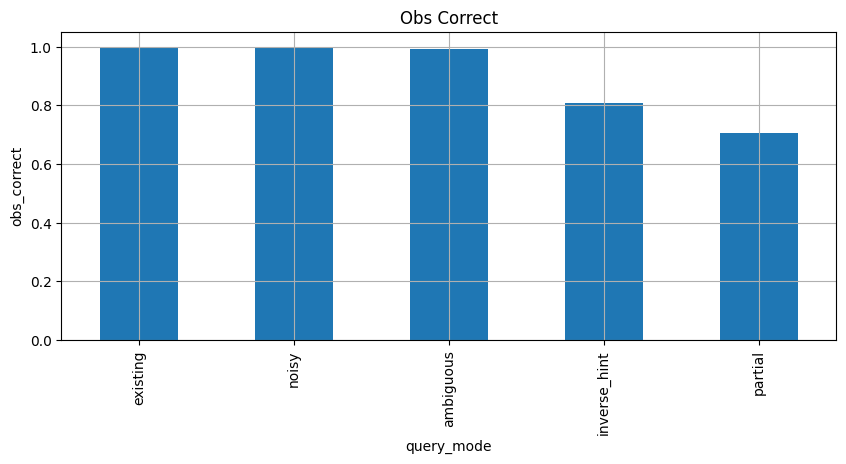

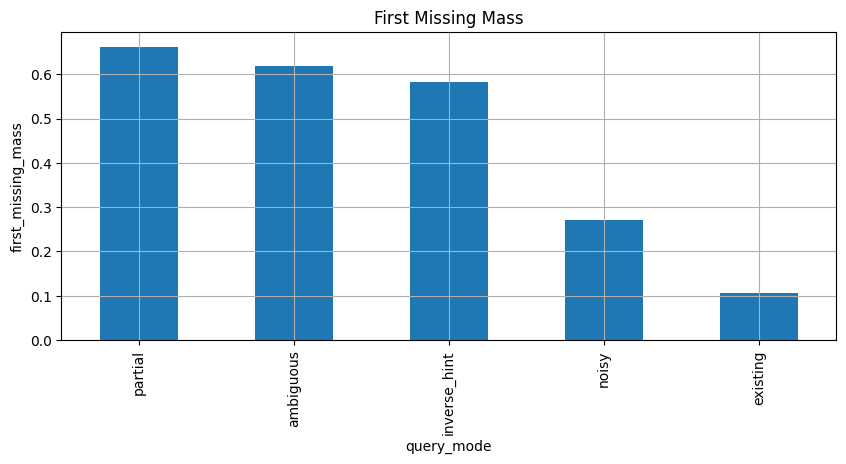

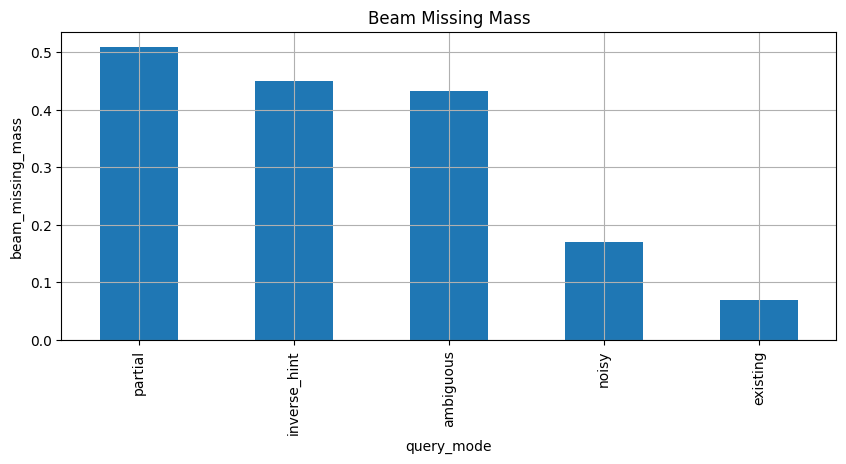

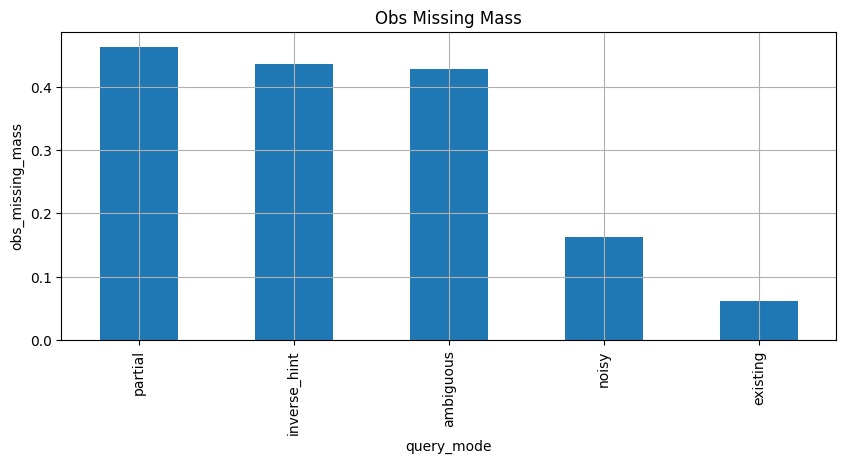

In [19]:

metrics = [
    "first_correct",
    "beam_correct",
    "obs_correct",
    "first_missing_mass",
    "beam_missing_mass",
    "obs_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


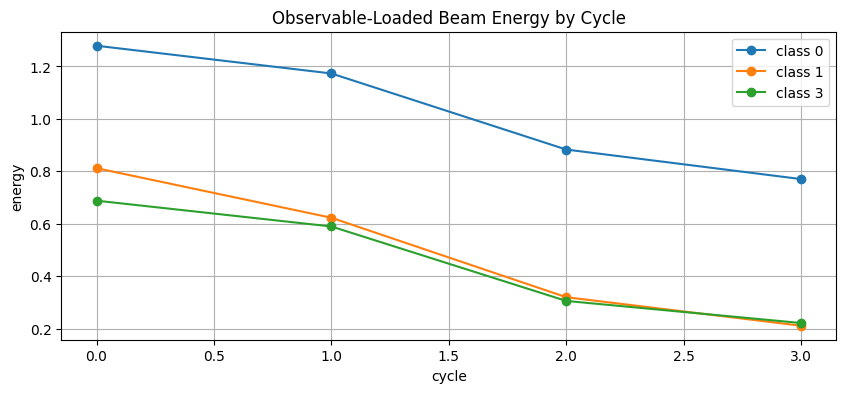

In [20]:

plt.figure(figsize=(10, 4))
for cls in sorted(obs_trace_df["class"].unique()):
    df = obs_trace_df[obs_trace_df["class"] == cls]
    plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
plt.title("Observable-Loaded Beam Energy by Cycle")
plt.xlabel("cycle")
plt.ylabel("energy")
plt.legend()
plt.show()


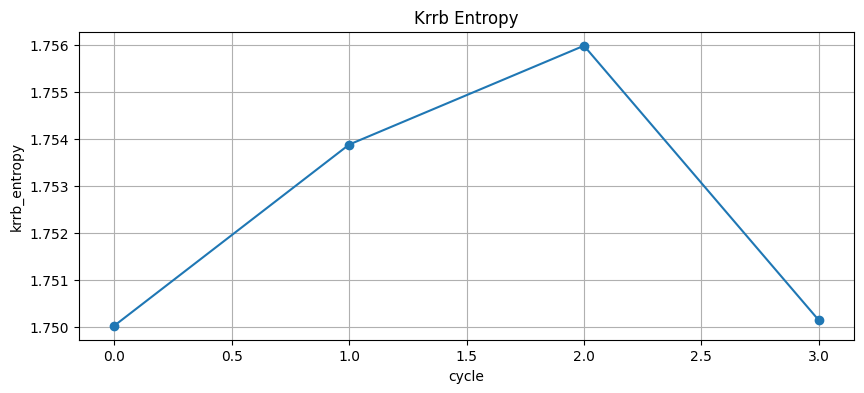

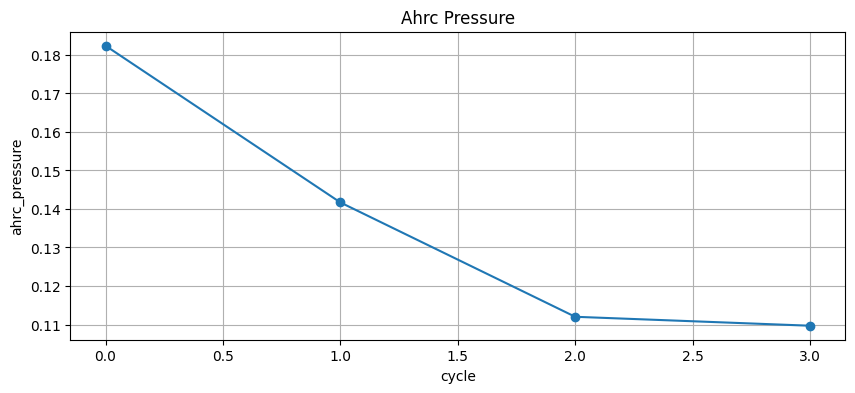

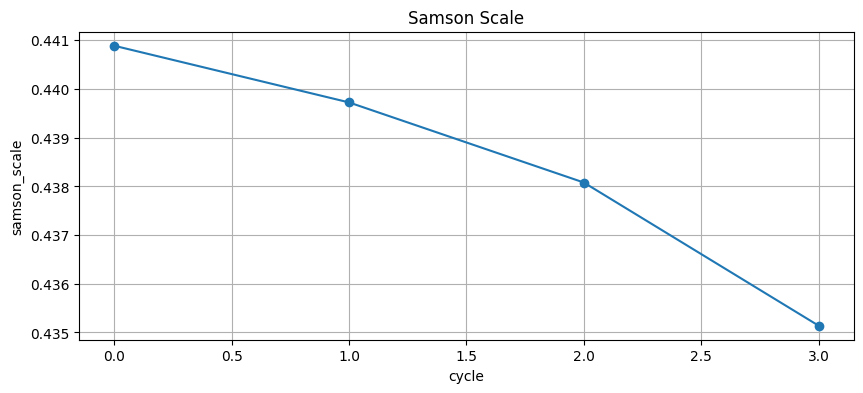

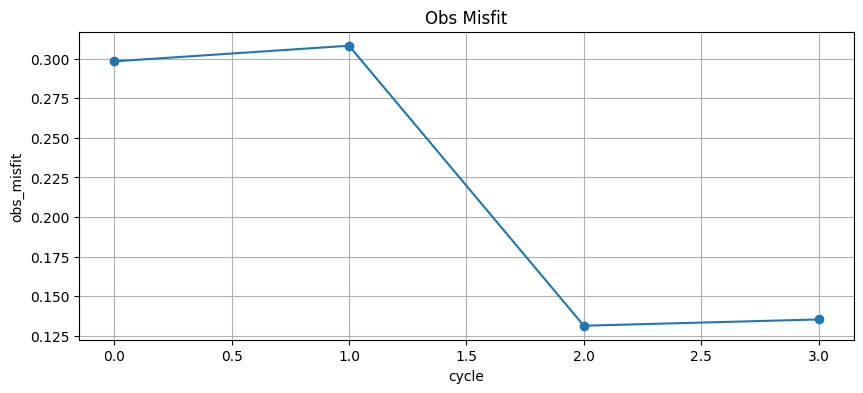

In [21]:

obs_metrics = ["krrb_entropy", "ahrc_pressure", "samson_scale", "obs_misfit"]

for metric in obs_metrics:
    plt.figure(figsize=(10, 4))
    plt.plot(obs_trace_df.groupby("cycle")[metric].mean(), marker="o")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("cycle")
    plt.ylabel(metric)
    plt.show()



## Practical readout

This notebook makes the key move explicit:

- the recursive loop receives new data as observable packets
- branches are selected by core fold energy plus observable misfit
- KRRB, SILR, Samson, and AHRC are measured as live beam outcomes

The first tables to read are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `observables_summary`
- `obs_trace_df`

The main question is:
does loading data through observables help the recursive beam?
